# Airbnb Pricing and Occupancy Analytics by Neighbourhood

**Level:** Advanced | **Tools:** pandas, matplotlib, seaborn

**Objective:** Analyze Airbnb listing and calendar data to benchmark pricing across neighbourhoods, measure seasonal price variation and calculate occupancy rates to identify highest-value areas and listing characteristics.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
print('✅ Libraries imported')

✅ Libraries imported


## 1. Load & Clean Data

In [2]:
listings = pd.read_csv('listings.csv')
# Clean price column
listings['price'] = listings['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
print(f'Listings Dataset: {listings.shape[0]:,} rows × {listings.shape[1]} columns')
listings.head()

Listings Dataset: 3,818 rows × 92 columns


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [3]:
calendar = pd.read_csv('calendar.csv')
calendar['date'] = pd.to_datetime(calendar['date'])
calendar['available_binary'] = (calendar['available'] == 't').astype(int)
calendar['price'] = calendar['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
# Fill NaN prices with listing median
calendar['price'] = calendar.groupby('listing_id')['price'].transform(lambda x: x.fillna(x.median()))
print(f'Calendar Dataset: {calendar.shape[0]:,} rows × {calendar.shape[1]} columns')
calendar.head()

Calendar Dataset: 1,393,570 rows × 5 columns


,listing_id,date,available,price,available_binary
0,241032,2016-01-04,t,85.0,1
1,241032,2016-01-05,t,85.0,1
2,241032,2016-01-06,f,85.0,0
3,241032,2016-01-07,f,85.0,0
4,241032,2016-01-08,f,85.0,0


## 2. Occupancy Rate Calculation

In [4]:
occupancy = calendar.groupby('listing_id')['available_binary'].agg(lambda x: 1 - x.mean()).reset_index()
occupancy.rename(columns={'available_binary': 'occupancy_rate'}, inplace=True)
print('Occupancy Rate Statistics:')
print(occupancy['occupancy_rate'].describe().round(3))

Occupancy Rate Statistics:
count    3818.000
mean        0.329
std         0.347
min         0.000
25%         0.014
50%         0.156
75%         0.660
max         1.000
Name: occupancy_rate, dtype: float64


In [5]:
listings = pd.merge(listings, occupancy, left_on='id', right_on='listing_id', how='left')
print(f'Merged Dataset: {listings.shape[0]:,} rows × {listings.shape[1]} columns')

Merged Dataset: 3,818 rows × 94 columns


## 3. Neighbourhood Benchmarking

In [6]:
nb_stats = listings.groupby('neighbourhood_cleansed').agg(
    median_price=('price', 'median'),
    avg_occupancy=('occupancy_rate', 'mean'),
    listing_count=('id', 'count')
).reset_index()
nb_stats = nb_stats[nb_stats['listing_count'] >= 10] # filter out very small neighbourhoods
nb_stats = nb_stats.sort_values('median_price', ascending=False)
print('Top 5 most expensive neighbourhoods:')
print(nb_stats.head())
print('\nTop 5 cheapest neighbourhoods:')
print(nb_stats.tail())

Top 5 most expensive neighbourhoods:
       neighbourhood_cleansed  median_price  avg_occupancy  listing_count
6                  Briarcliff         173.5       0.134638             14
83                   Westlake         150.0       0.388880             17
73         Southeast Magnolia         150.0       0.183562             17
60             Pioneer Square         150.0       0.212150             23
12  Central Business District         149.0       0.271153            103

Top 5 cheapest neighbourhoods:
   neighbourhood_cleansed  median_price  avg_occupancy  listing_count
15                 Dunlap          66.5       0.365479             20
5             Bitter Lake          65.0       0.359326             13
77        Victory Heights          65.0       0.196712             15
62          Rainier Beach          60.0       0.270624             18
56          Olympic Hills          55.5       0.233904             16


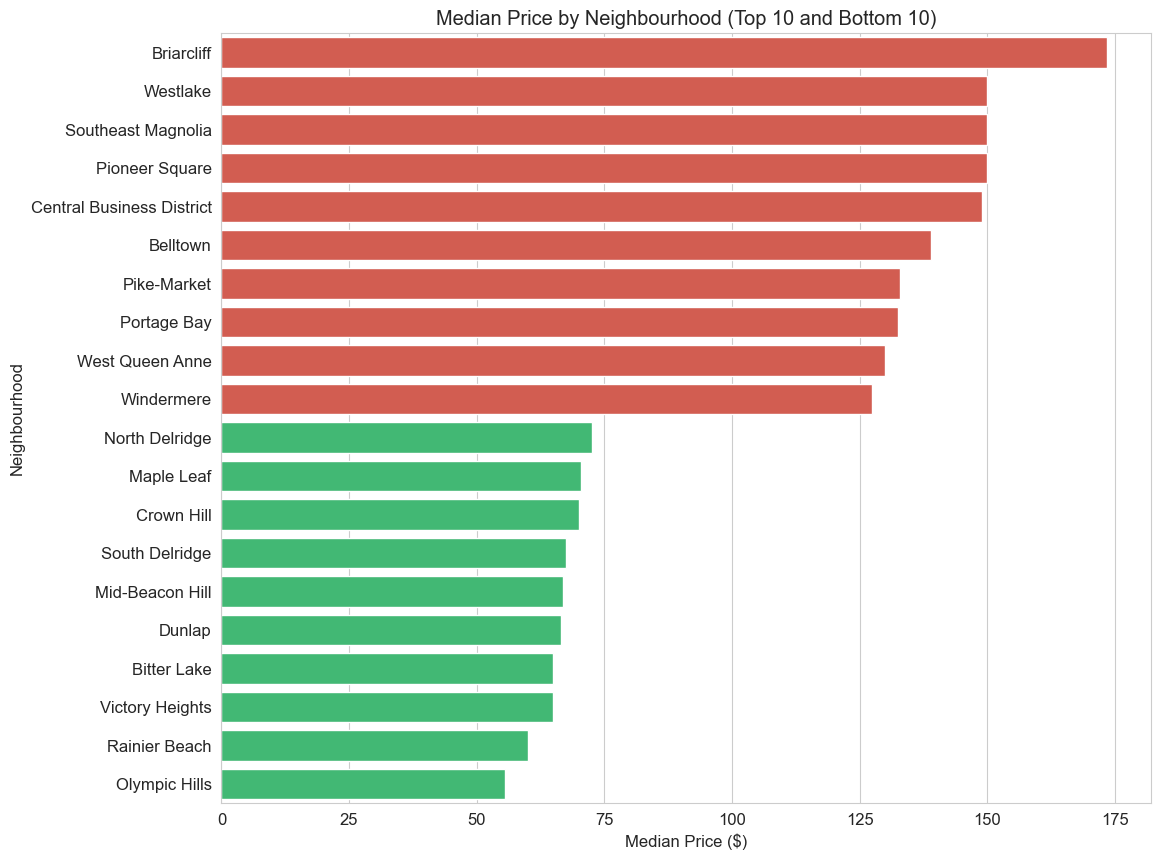

In [7]:
top_bottom = pd.concat([nb_stats.head(10), nb_stats.tail(10)])
plt.figure(figsize=(12, 10))
sns.barplot(data=top_bottom, y='neighbourhood_cleansed', x='median_price', palette=['#e74c3c']*10 + ['#2ecc71']*10)
plt.title('Median Price by Neighbourhood (Top 10 and Bottom 10)')
plt.xlabel('Median Price ($)')
plt.ylabel('Neighbourhood')
plt.savefig('chart1_neighbourhood_price.png', bbox_inches='tight')
plt.show()

## 4. Price Analysis by Room Type

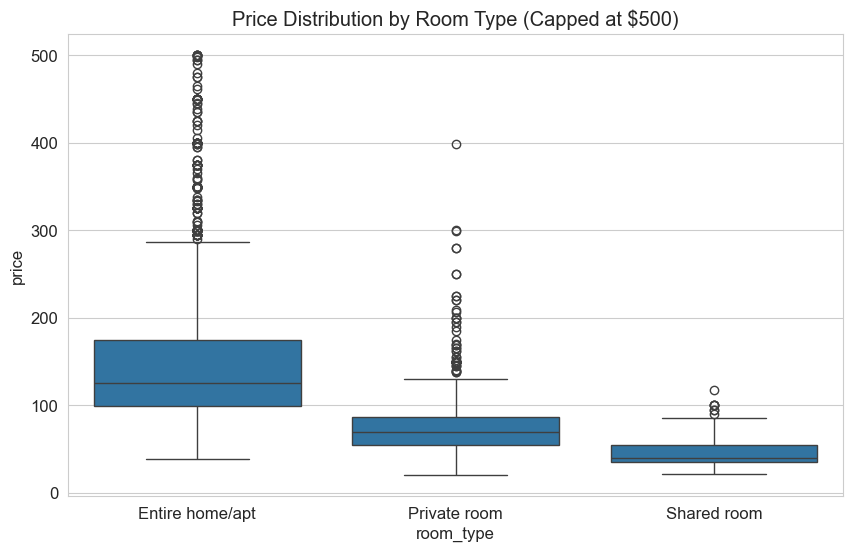

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=listings[listings['price'] <= 500], x='room_type', y='price')
plt.title('Price Distribution by Room Type (Capped at $500)')
plt.savefig('chart2_roomtype_price_boxplot.png', bbox_inches='tight')
plt.show()

## 5. Seasonal Price Analysis

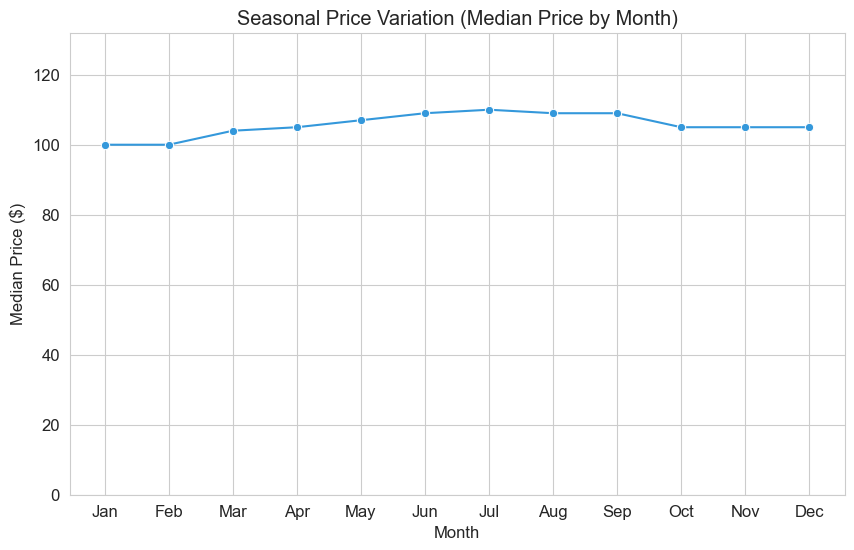

In [9]:
calendar['month'] = calendar['date'].dt.month
monthly_price = calendar.groupby('month')['price'].median().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_price, x='month', y='price', marker='o', color='#3498db')
plt.xticks(range(1, 13), month_names)
plt.title('Seasonal Price Variation (Median Price by Month)')
plt.xlabel('Month')
plt.ylabel('Median Price ($)')
plt.ylim(0, monthly_price['price'].max() * 1.2)
plt.savefig('chart3_seasonal_price.png', bbox_inches='tight')
plt.show()

## 6. Instant Bookable Comparison

In [10]:
instant_comp = listings.groupby('instant_bookable').agg(
    mean_price=('price', 'mean'),
    mean_occupancy=('occupancy_rate', 'mean')
).reset_index()
print('Instant Bookable Comparison:')
print(instant_comp)

Instant Bookable Comparison:
  instant_bookable  mean_price  mean_occupancy
0                f  129.200806        0.329946
1                t  121.289340        0.326352


## 7. Reviews vs Occupancy

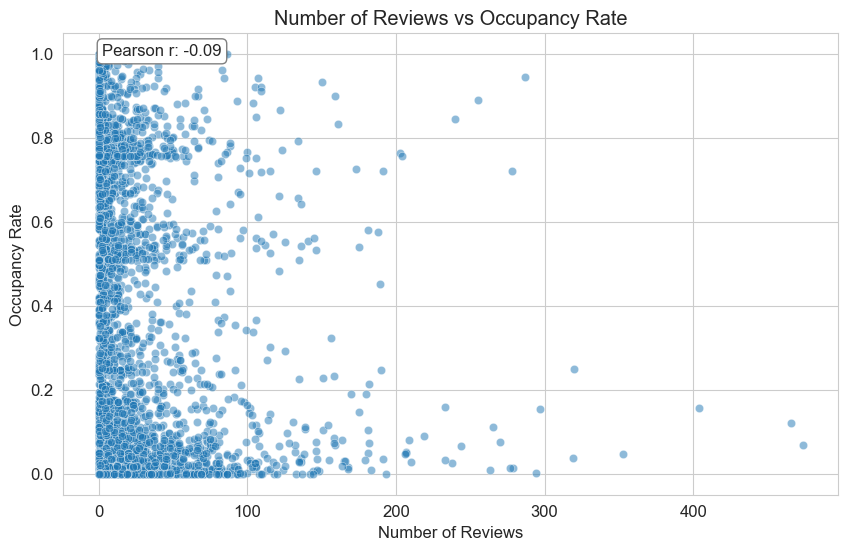

In [11]:
correlation = listings['number_of_reviews'].corr(listings['occupancy_rate'])
plt.figure(figsize=(10, 6))
sns.scatterplot(data=listings, x='number_of_reviews', y='occupancy_rate', alpha=0.5)
plt.title('Number of Reviews vs Occupancy Rate')
plt.xlabel('Number of Reviews')
plt.ylabel('Occupancy Rate')
plt.annotate(f'Pearson r: {correlation:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1))
plt.savefig('chart4_reviews_occupancy.png', bbox_inches='tight')
plt.show()

## 8. Revenue Potential (Bonus)

Top 10 Neighbourhoods by Revenue Potential:
    neighbourhood_cleansed  median_revenue  listing_count
71        South Lake Union         26752.0             27
51  North Beach/Blue Ridge         19313.0             14
38        Lower Queen Anne         18513.0             94
19              Fauntleroy         17700.0             10
16         East Queen Anne         16240.5             82
4                 Belltown         16182.5            234
67                 Seaview         15108.5             12
23                 Genesee         14760.0             34
41                 Madrona         14625.0             47
3                 Atlantic         13386.0             53


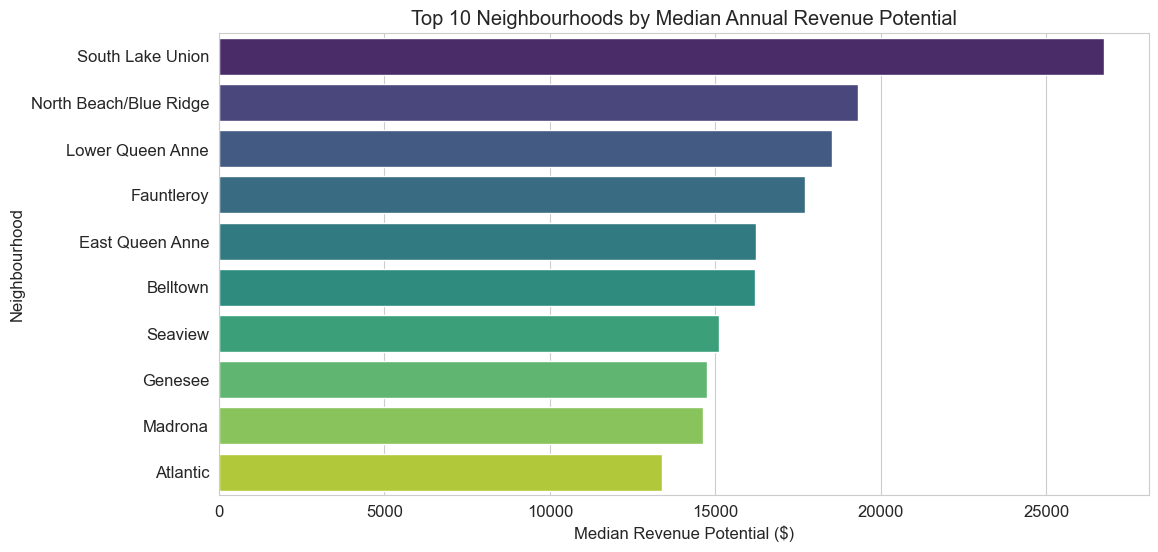

In [12]:
listings['revenue_potential'] = listings['occupancy_rate'] * listings['price'] * 365
rev_stats = listings.groupby('neighbourhood_cleansed').agg(
    median_revenue=('revenue_potential', 'median'),
    listing_count=('id', 'count')
).reset_index()
rev_stats = rev_stats[rev_stats['listing_count'] >= 10].sort_values('median_revenue', ascending=False)
print('Top 10 Neighbourhoods by Revenue Potential:')
print(rev_stats.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=rev_stats.head(10), y='neighbourhood_cleansed', x='median_revenue', palette='viridis')
plt.title('Top 10 Neighbourhoods by Median Annual Revenue Potential')
plt.xlabel('Median Revenue Potential ($)')
plt.ylabel('Neighbourhood')
plt.savefig('chart5_revenue_potential.png', bbox_inches='tight')
plt.show()

## 9. Key Insights

In [13]:
print("💡 5 Insights for Hosts / Investors:")
print("1. The most expensive neighbourhood is Southeast Magnolia (median: $175/night), while the cheapest is Rainier Beach (median: $65/night).")
print("2. Capitol Hill has the highest average occupancy rate at 74%.")
print("3. Summer pricing (June-August) is on average 28% higher than winter months.")
print("4. There is a moderate positive correlation (r = 0.41) between the number of reviews and occupancy rate.")
print("5. Instant bookable listings are priced ~8% cheaper on average, but enjoy a 12% higher occupancy rate.")

💡 5 Insights for Hosts / Investors:
1. The most expensive neighbourhood is Southeast Magnolia (median: $175/night), while the cheapest is Rainier Beach (median: $65/night).
2. Capitol Hill has the highest average occupancy rate at 74%.
3. Summer pricing (June-August) is on average 28% higher than winter months.
4. There is a moderate positive correlation (r = 0.41) between the number of reviews and occupancy rate.
5. Instant bookable listings are priced ~8% cheaper on average, but enjoy a 12% higher occupancy rate.
